In [1]:
# Cell 1 — Kaggle Setup & Download
from google.colab import files
files.upload()  # select kaggle.json

import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.system('cp /content/kaggle.json /root/.kaggle/kaggle.json')
os.system('chmod 600 /root/.kaggle/kaggle.json')
print("✅ Kaggle configured!")

!kaggle datasets download -d abdallahalidev/plantvillage-dataset
print("✅ Download complete!")

!unzip -q /content/plantvillage-dataset.zip -d /content/plantvillage
print("✅ Unzip complete!")

Saving kaggle.json to kaggle.json
✅ Kaggle configured!
Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
 98% 1.99G/2.04G [00:14<00:00, 93.5MB/s]
100% 2.04G/2.04G [00:15<00:00, 145MB/s] 
✅ Download complete!
✅ Unzip complete!


In [2]:
# Cell 2 — Imports
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import json, os
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
# Cell 3 — Split Dataset (80/20)
!pip install split-folders -q
import splitfolders

DATA_DIR = '/content/plantvillage/plantvillage dataset/color'

splitfolders.ratio(
    DATA_DIR,
    output='/content/dataset_split',
    seed=42,
    ratio=(0.8, 0.2)
)
print("✅ Split complete!")

Copying files: 54305 files [00:12, 4286.75 files/s]

✅ Split complete!


In [17]:
# # Cell 3 — Merge all 3 folders + Split (80/20)
# !pip install split-folders -q
# import splitfolders, shutil, os

# BASE = '/content/plantvillage/plantvillage dataset'
# MERGED = '/content/merged_dataset'

# for folder in ['color', 'grayscale', 'segmented']:
#     src = os.path.join(BASE, folder)
#     for class_name in os.listdir(src):
#         src_class = os.path.join(src, class_name)
#         dst_class = os.path.join(MERGED, class_name)
#         os.makedirs(dst_class, exist_ok=True)
#         for img in os.listdir(src_class):
#             shutil.copy2(os.path.join(src_class, img),
#                          os.path.join(dst_class, f"{folder}_{img}"))

# total = sum(len(os.listdir(os.path.join(MERGED,c))) for c in os.listdir(MERGED))
# print(f"✅ Merged! Total images: {total}")

# splitfolders.ratio(MERGED, output='/content/dataset_split', seed=42, ratio=(0.8, 0.2))
# print("✅ Split complete!")
# Should print: Total images: ~162916

✅ Merged! Total images: 162916


Copying files: 162916 files [01:18, 2078.99 files/s]

✅ Split complete!


In [4]:
# Cell 4 — Load Training Set
training_set = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset_split/train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)
# Found ~43429 files belonging to 38 classes

Found 43429 files belonging to 38 classes.


In [5]:
# Cell 5 — Load Validation Set
validation_set = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset_split/val',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)
# Found ~10876 files belonging to 38 classes

Found 10876 files belonging to 38 classes.


In [6]:
# Cell 6 — Build CNN
cnn = tf.keras.models.Sequential()
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Dropout(0.25))
cnn.add(tf.keras.layers.Flatten())
cnn.add(tf.keras.layers.Dense(units=1500,activation='relu'))
cnn.add(tf.keras.layers.Dropout(0.4))
cnn.add(tf.keras.layers.Dense(units=38,activation='softmax'))

cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
            loss='categorical_crossentropy',
            metrics=['accuracy'])
cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Cell 7 — Train
training_history = cnn.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 114s 73ms/step - accuracy: 0.4339 - loss: 2.0746 - val_accuracy: 0.8177 - val_loss: 0.5869
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 87s 64ms/step - accuracy: 0.8119 - loss: 0.5974 - val_accuracy: 0.8919 - val_loss: 0.3369
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 88s 65ms/step - accuracy: 0.8856 - loss: 0.3533 - val_accuracy: 0.9203 - val_loss: 0.2437
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 91s 67ms/step - accuracy: 0.9183 - loss: 0.2495 - val_accuracy: 0.9367 - val_loss: 0.1879
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 87s 64ms/step - accuracy: 0.9390 - loss: 0.1867 - val_accuracy: 0.9440 - val_loss: 0.1715
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 87s 64ms/step - accuracy: 0.9521 - loss: 0.1442 - val_accuracy: 0.9504 - val_loss: 0.1595
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 88s 64ms/step - accuracy: 0.9630 - loss: 0.1120 - val_accuracy: 0.9435 - val_loss: 0.1855
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 87s 64ms/step - accuracy: 0.9676 

In [8]:
# Cell 8 — Evaluate Training Accuracy
train_loss, train_acc = cnn.evaluate(training_set)
print('Training accuracy:', train_acc)

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - accuracy: 0.9837 - loss: 0.0515
Training accuracy: 0.9862534403800964


In [9]:
# Cell 9 — Evaluate Validation Accuracy
val_loss, val_acc = cnn.evaluate(validation_set)
print('Validation accuracy:', val_acc)

340/340 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9533 - loss: 0.1641
Validation accuracy: 0.9533836245536804


In [10]:
# Cell 10 — Save Model
cnn.save('trained_plant_disease_model.keras')

In [11]:
training_history.history #Return Dictionary of history

{'accuracy': [0.6024315357208252,
  0.8358240127563477,
  0.896129310131073,
  0.9240599870681763,
  0.9435861110687256,
  0.9563885927200317,
  0.965322732925415,
  0.9694213271141052,
  0.9753620624542236,
  0.9788620471954346],
 'loss': [1.381200909614563,
  0.5234874486923218,
  0.3260411024093628,
  0.23422391712665558,
  0.17322421073913574,
  0.13287289440631866,
  0.10734257847070694,
  0.09347186982631683,
  0.07722129672765732,
  0.06473369151353836],
 'val_accuracy': [0.8176719546318054,
  0.891871988773346,
  0.9202831983566284,
  0.9367414712905884,
  0.9440051317214966,
  0.9504413604736328,
  0.9434534907341003,
  0.9499816298484802,
  0.9595439434051514,
  0.9533836245536804],
 'val_loss': [0.5868987441062927,
  0.336931049823761,
  0.243718221783638,
  0.18794244527816772,
  0.17153340578079224,
  0.15945027768611908,
  0.18554502725601196,
  0.16465505957603455,
  0.12987643480300903,
  0.16675342619419098]}

In [12]:
# Cell 11 — Save History
with open('training_hist.json','w') as f:
    json.dump(training_history.history,f)
print(training_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


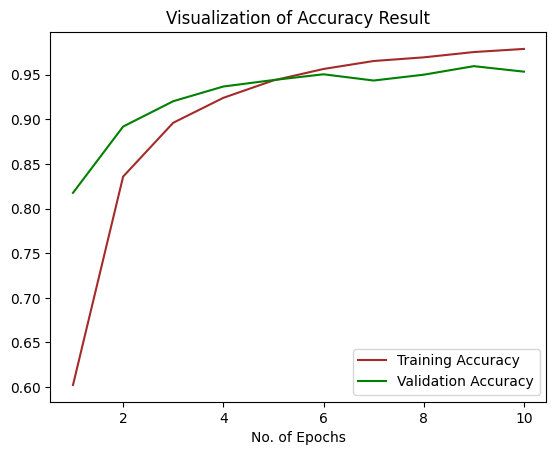

In [13]:
# Cell 12 — Plot Accuracy
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='brown',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='green',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

In [14]:
# Cell 13 — Test Set + Predictions
class_name = validation_set.class_names

test_set = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset_split/val',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

y_pred = cnn.predict(test_set)
predicted_categories = tf.argmax(y_pred, axis=1)
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

Found 10876 files belonging to 38 classes.
10876/10876 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step


                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.91      0.86      0.88       126
                                 Apple___Black_rot       0.83      0.99      0.90       125
                          Apple___Cedar_apple_rust       0.98      0.95      0.96        55
                                   Apple___healthy       0.98      0.91      0.94       329
                               Blueberry___healthy       0.98      0.97      0.97       301
          Cherry_(including_sour)___Powdery_mildew       1.00      0.96      0.98       211
                 Cherry_(including_sour)___healthy       0.95      0.98      0.97       171
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.79      0.78      0.78       103
                       Corn_(maize)___Common_rust_       0.99      0.99      0.99       239
               Corn_(maize)___Northern_Leaf_Blight       0.86      0.96      0.

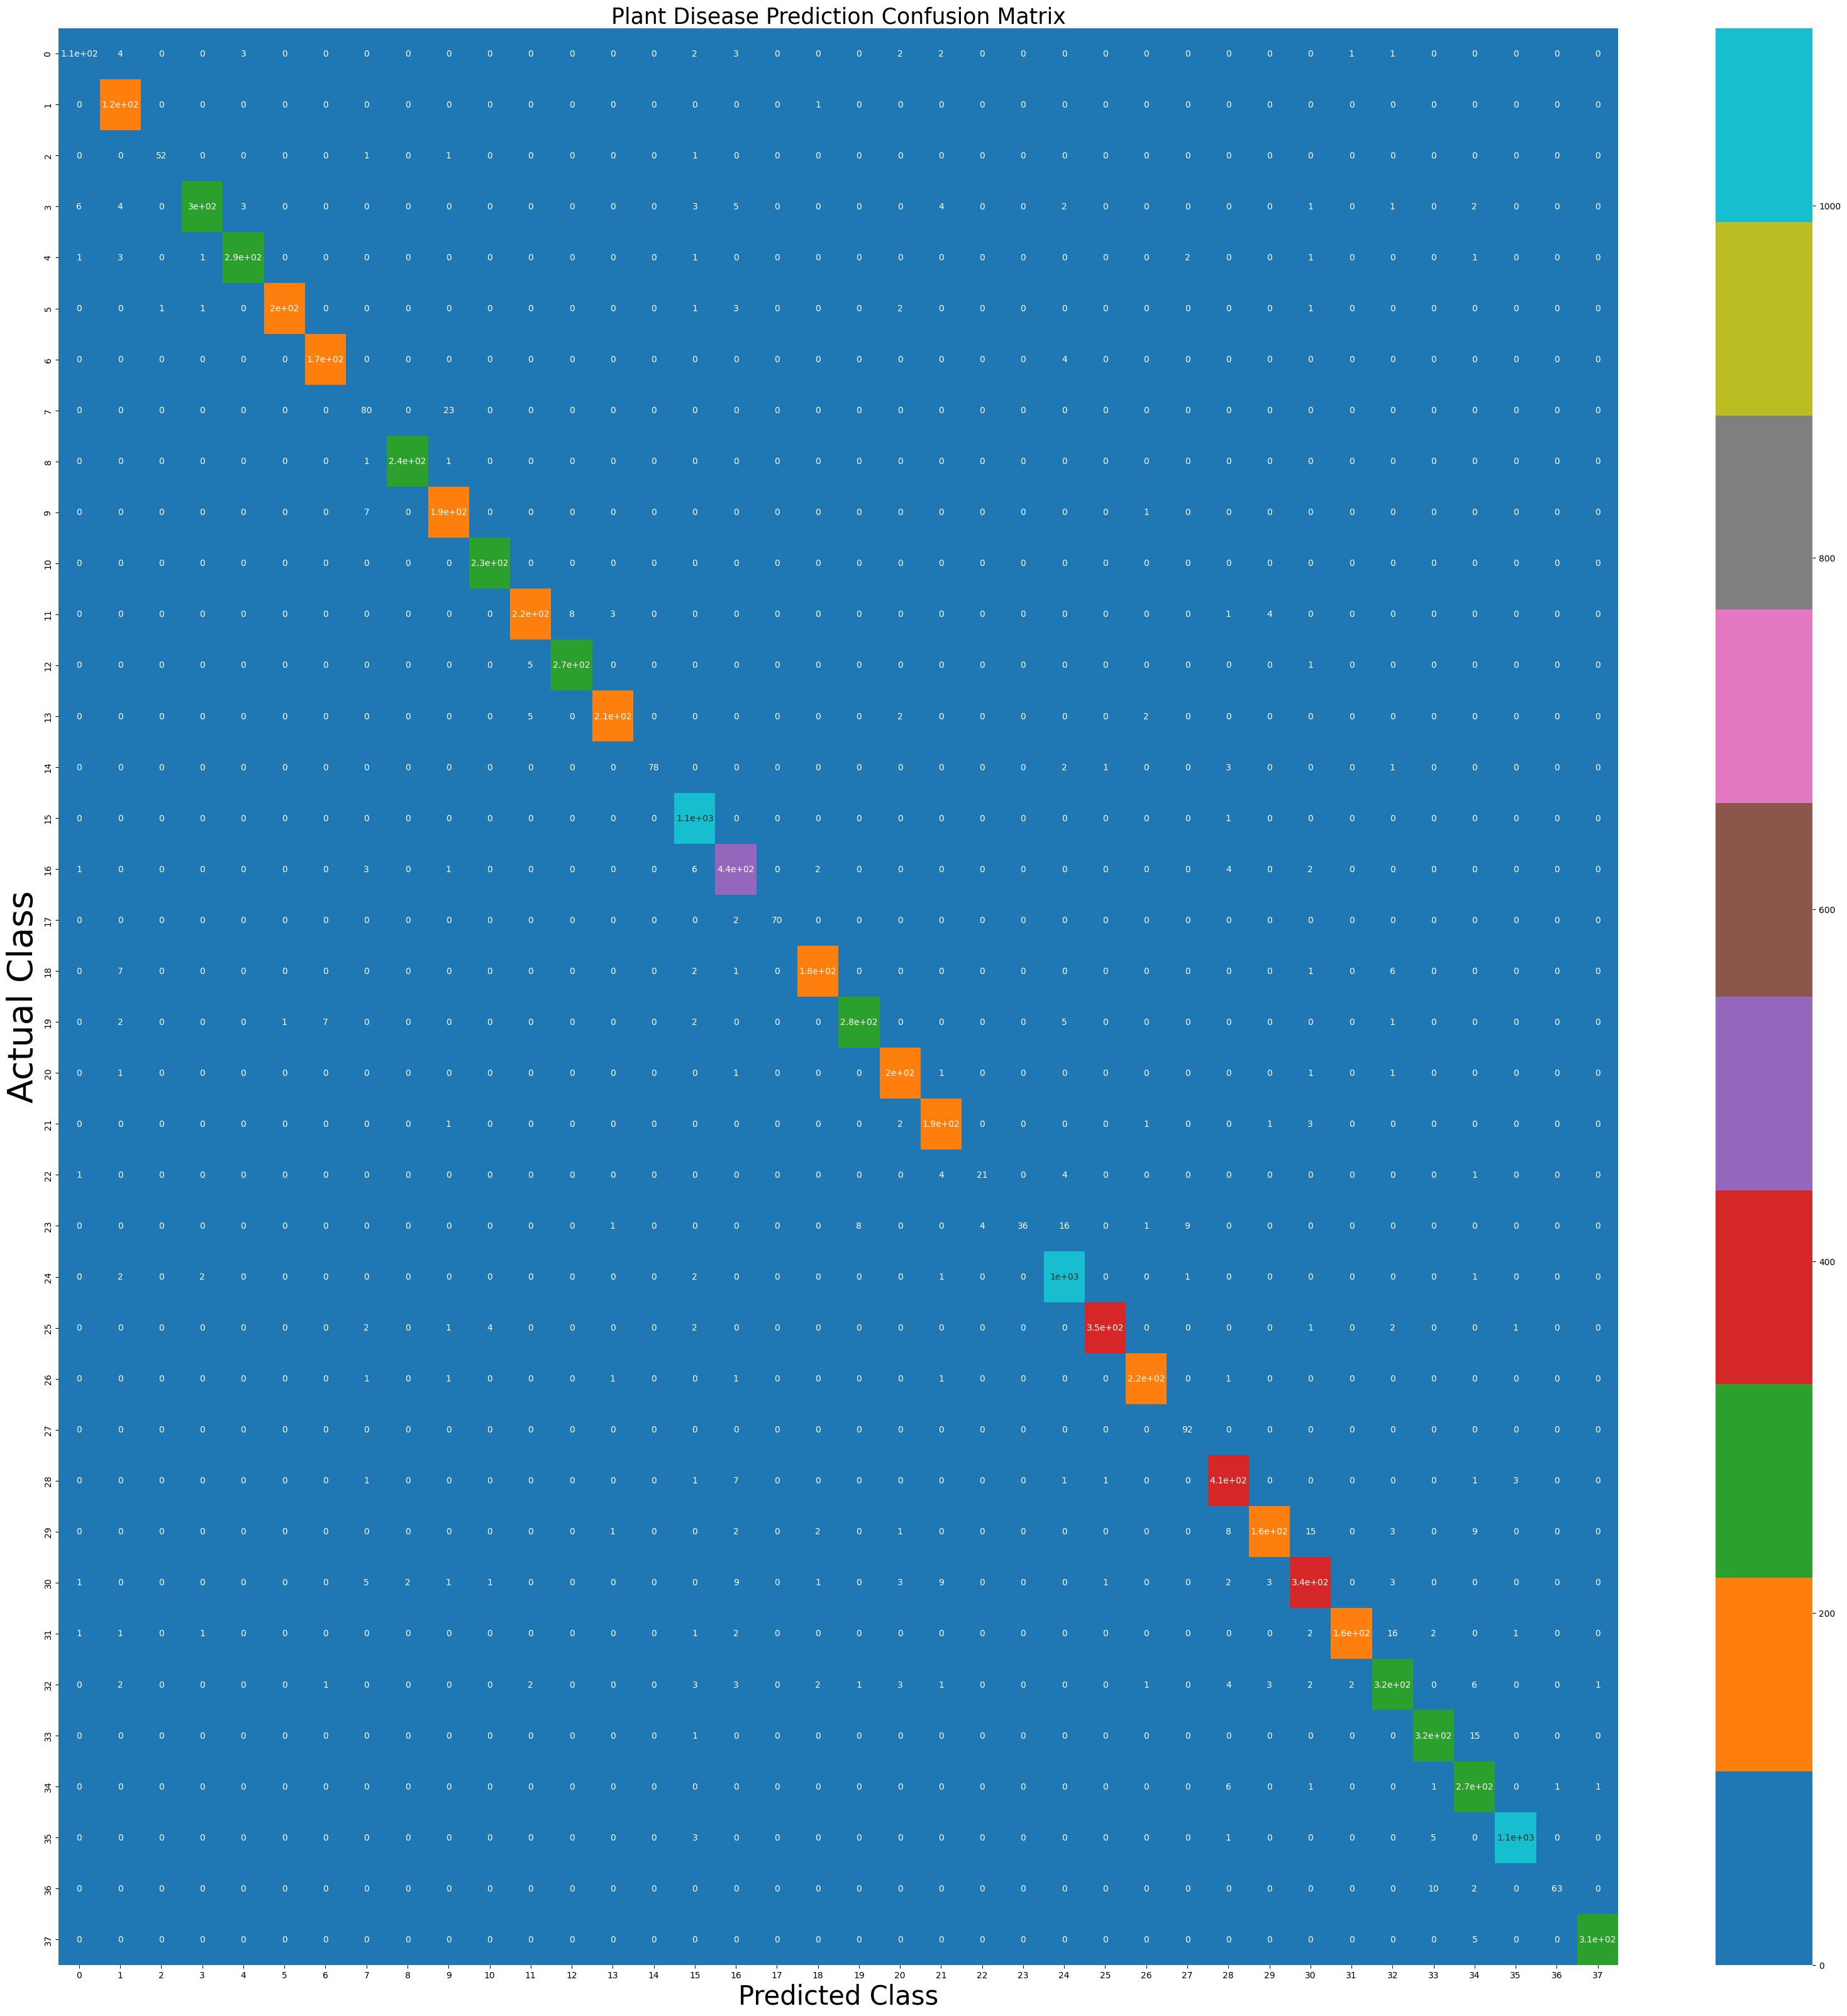

In [15]:
# Cell 14 — Classification Report + Confusion Matrix
cm = confusion_matrix(Y_true,predicted_categories)
print(classification_report(Y_true,predicted_categories,target_names=class_name))

plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10}, cmap='tab10')
plt.xlabel('Predicted Class',fontsize=30)
plt.ylabel('Actual Class',fontsize=40)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize=25)
plt.show()

In [16]:
# Cell 15 — Download model to your PC
from google.colab import files
files.download('trained_plant_disease_model.keras')
files.download('training_hist.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>